In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import gzip

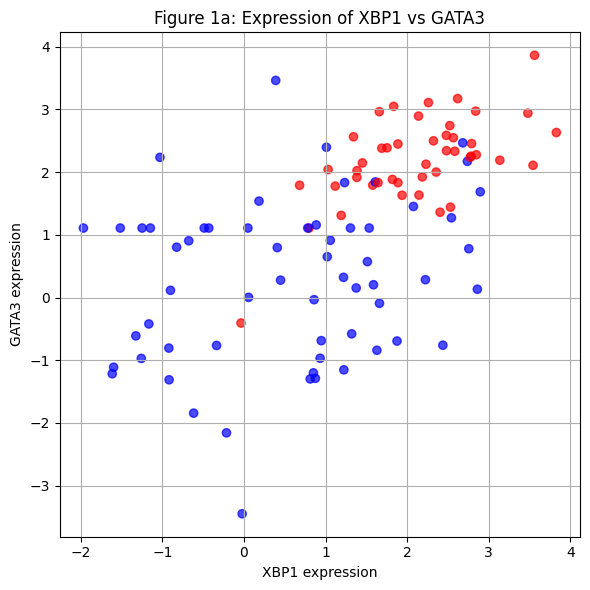

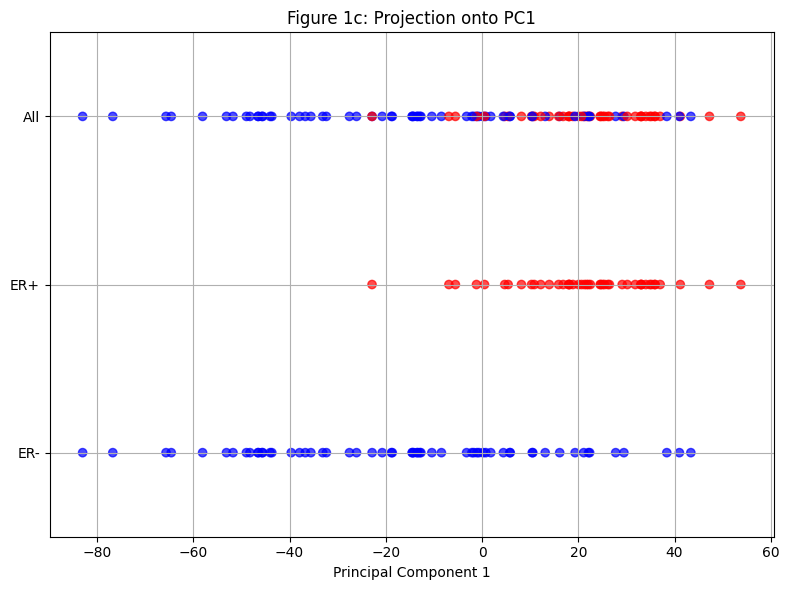

In [28]:
class_df = pd.read_csv("class.tsv", sep="\t", header=None, names=["Class"])["Class"]

# Load gene ID to symbol mapping
with gzip.open("columns.tsv.gz", 'rt') as f:
    columns_df = pd.read_csv(f, sep = "\t", comment = "#")

# Get only ID and GeneSymbol
columns_df = columns_df[["ID", "GeneSymbol"]].dropna()

genes = columns_df.set_index("GeneSymbol").loc[["XBP1", "GATA3"]]
geneid = genes["ID"].astype(str)

# Find IDs for XBP1 and GATA3
xbp1_id = geneid["XBP1"]
gata3_id = geneid["GATA3"]

# Load gene expression data
with gzip.open("filtered.tsv.gz", 'rt') as f:
    expression_df = pd.read_csv(f, sep="\t")

expression_df.columns = expression_df.columns.str.strip()

# Extract XBP1 and GATA3 expression
expr_subset = expression_df[[xbp1_id, gata3_id]]
expr_subset.columns = ["XBP1", "GATA3"]

# Plot Figure 1a-like scatter plot
plt.figure(figsize=(6, 6))
colors = class_df.map({1: "red", 0: "blue"})
plt.scatter(expr_subset["XBP1"], expr_subset["GATA3"], c=colors, alpha=0.7)
plt.xlabel("XBP1 expression")
plt.ylabel("GATA3 expression")
plt.title("Figure 1a: Expression of XBP1 vs GATA3")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------- PCA ANALYSIS --------
# Standardize the data (without class column)
features = expr_subset[["XBP1", "GATA3"]]
features_scaled = StandardScaler().fit_transform(features)

# Apply PCA
pca = PCA(n_components=1)
pc1 = pca.fit_transform(expression_df)

values = class_df.values
pc1_extended = np.concatenate([pc1, pc1])
values_extended = np.concatenate([values, np.full(len(values), 2)])
colors_extended = np.concatenate([colors, colors])

# Plot Figure 1c-like projection onto PC1
plt.figure(figsize=(8, 6))
plt.scatter(pc1_extended, values_extended, c=colors_extended, alpha=0.7)
plt.xlabel("Principal Component 1")
plt.title("Figure 1c: Projection onto PC1")
plt.yticks([0,1,2], ["ER-", "ER+", "All"])
plt.ylim(-0.5,2.5)
plt.grid(True)
plt.tight_layout()
plt.show()